## Variable Selection for h5 files

### *–––– Set up ––––*

In [1]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json

NanoAODSchema.warn_missing_crossrefs = False

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [2]:
import json

with open("samples.json", 'r') as sample_file:
    fileset = json.load(sample_file)

for sample in fileset:
    print(sample)

BulkGravToWW_1000
BulkGravToWW_2000
RSGravToWW_1200
RSGravToWW_2000


In [14]:
test_dataset = 'RSGravToWW_2000'
events = NanoEventsFactory.from_root(
    fileset[test_dataset]['files'],
    entry_stop = 10000,
    metadata = fileset[test_dataset]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()

### *–––– STEP 1: Tight Lepton Selection ––––*

In [15]:
muons = events.Muon
electrons = events.Electron

# Muon Tight selection
muons_tight = muons[
    (muons.pt > 40) &
    (muons.eta < 2.4) &
    (muons.tightId) &
    (
        ((muons.pt < 10) & (muons.dxy < 0.01)) |
        ((muons.pt >= 10) & (muons.dxy < 0.02))
    ) &
    (muons.dz < 0.05) # &
    # particle flow isolated: tight or greater
    # (muons.pfIsoId >= 4)
]

print(f"{len(ak.flatten(muons_tight))} out of {len(ak.flatten(muons))} muons pass the tight selection")

# Electron Tight selection

electrons_tight = electrons[
    (electrons.pt > 35) &
    (electrons.eta < 2.4) &  # barrel + endcap
    # (electrons.mvaFall17V2Iso_WP90 == True) &
    (
        ((electrons.pt < 15) & (electrons.dxy < 0.01)) |
        ((electrons.pt >= 15) & (electrons.dxy < 0.02))
    ) &
    # (electrons.cutBased >= 1) &      # tight cut-based ID
    (electrons.dxy < 0.05) & # dxy tighter
    (electrons.dz < 0.05) &
    (electrons.pfRelIso03_all < 0.15) &  # isolated
    (electrons.lostHits <= 1) &
    (electrons.convVeto == True)
]

print(f"{ len(ak.flatten(electrons_tight))} out of {len(ak.flatten(electrons))} electrons pass the tight selection")

2285 out of 4747 muons pass the tight selection
2252 out of 7358 electrons pass the tight selection


In [5]:
# muons.fields
# electrons.fields

In [16]:
# Count of tight leptons
tight_muon_count = ak.num(muons_tight)
tight_electron_count = ak.num(electrons_tight)

# --- Loose leptons for vetoing ---
# loose_muons = muons[muons.looseId]
loose_muons = muons[(muons.isPFcand) & (muons.mediumId) & (muons.pfRelIso03_all < 0.4)]
loose_muons = loose_muons[loose_muons.pt > 10]

loose_electrons = electrons[electrons.cutBased >= 2]
loose_electrons = loose_electrons[loose_electrons.pt > 10]

# Count of loose leptons
loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)

# --- Event selection mask: exactly one tight lepton and no extra loose leptons ---
single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)

# Apply mask to get final event selection
events_selected = events[single_lepton_mask]

print(f"{len(events_selected)} events {len(events)} passed the tight lepton selection and loose veto.")

3135 events 10000 passed the tight lepton selection and loose veto.


In [17]:
# Masks for exactly one tight lepton
one_tight_electron_mask = (tight_electron_count == 1) & (tight_muon_count == 0) & (loose_lepton_count == 1)
one_tight_muon_mask = (tight_muon_count == 1) & (tight_electron_count == 0) & (loose_lepton_count == 1)

# Apply masks to original tight collections
tight_electron_one = electrons_tight[one_tight_electron_mask]
tight_muon_one = muons_tight[one_tight_muon_mask]

#### *–––– Step 1: the plots ––––* 

In [217]:
# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(muons_tight.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [218]:
# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(electrons_tight.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [219]:
# plt.figure(figsize=(12, 5))

# # --- Electrons ---
# plt.subplot(1, 2, 1)
# plt.hist(ak.to_numpy(ak.flatten(tight_electron_one.pt)), bins=30, range=(0, 300), histtype='step', color='orange')
# plt.xlabel(r"Tight Electron $p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Events with Exactly One Tight Electron")
# plt.grid(True)

# # --- Muons ---
# plt.subplot(1, 2, 2)
# plt.hist(ak.to_numpy(ak.flatten(tight_muon_one.pt)), bins=30, range=(0, 300), histtype='step', color='green')
# plt.xlabel(r"Tight Muon $p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Events with Exactly One Tight Muon")
# plt.grid(True)

# plt.tight_layout()
# plt.show()

### *–––– STEP 2: AK8 Cleaning ––––*

In [41]:
# FatJets cuts
clean_fatJets = events.FatJet[(events.FatJet.pt > 200) & (abs(events.FatJet.eta) < 2.4) & (events.FatJet.msoftdrop > 20)]
20
#Jets cuts
clean_Jets = events.Jet[(events.Jet.pt > 40) & (events.Jet.eta < 4.6)]

In [42]:
#Removing AK4(Jet) jets overlapping with AK8(FatJets) jets
#1: Form all possible Jet–FatJet pairs per event
jets_fatjets = ak.cartesian({"x": clean_Jets, "y": clean_fatJets})
#2: Compute ΔR² separation between each Jet–FatJet pair
jets_iso_f = ((jets_fatjets["x"].eta-jets_fatjets["y"].eta)**2+(jets_fatjets["x"].phi-jets_fatjets["y"].phi)**2>0.8**2)
#3: Mask out jets with ΔR < 0.8 (i.e. remove overlapping jets)
jets_fatjets = jets_fatjets[jets_iso_f]
#4 Separate pairs into jets and fatjets, redefining the jets (but not the fatjets) 
jets, fj = ak.unzip(jets_fatjets)

In [43]:
# Require events with at least 1 clean AK8 FatJets
AK8jets_candidates_mask = ak.num(clean_fatJets) >= 1
Wjets_candidates = clean_fatJets[AK8jets_candidates_mask]

leading_W_jet = Wjets_candidates[:, 0]
leading_W_jet_pt = leading_W_jet.pt

In [44]:
# Require events with at least  clean AK8 FatJets
AK8jets_2_mask = ak.num(clean_fatJets) >= 2
Wjets_2_candidates = clean_fatJets[AK8jets_2_mask]

second_W_jet = Wjets_2_candidates[:, 1]
second_W_jet_pt = second_W_jet.pt

#### Step 2: plots

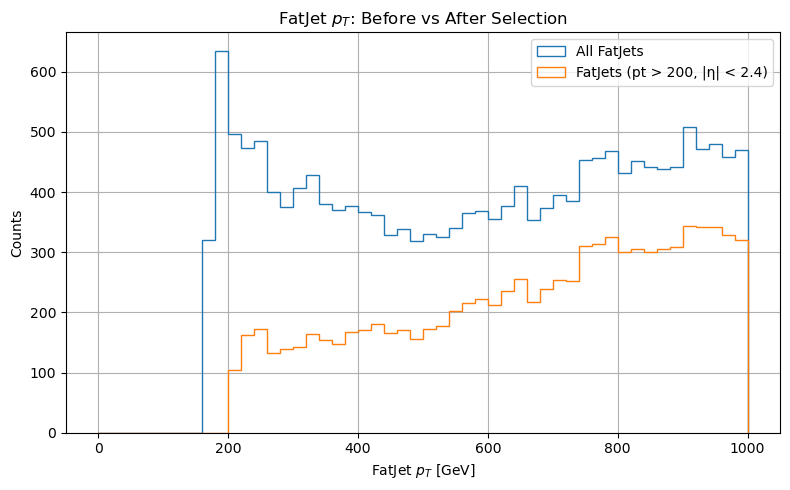

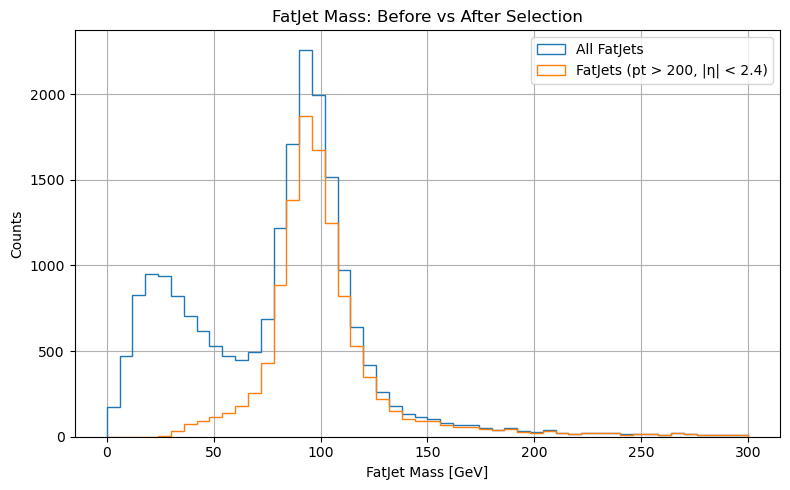

In [45]:
## FatJets before and after
# --- FatJet pT ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.pt)), bins=50, range=(0, 1000),
         histtype='step', label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=50, range=(0, 1000),
         histtype='step', label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("FatJet $p_T$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- FatJet mass ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.mass)), bins=50, range=(0, 300),
         histtype='step', label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.mass)), bins=50, range=(0, 300),
         histtype='step', label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet Mass [GeV]")
plt.ylabel("Counts")
plt.title("FatJet Mass: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
# ## Jets before and after 
# # --- Jet pT ---
# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(events.Jet.pt)), bins=50, range=(0, 500),
#          histtype='step', label='All Jets')
# plt.hist(ak.to_numpy(ak.flatten(clean_Jets.pt)), bins=50, range=(0, 500),
#          histtype='step', label='Jets (pt > 30, |η| < 4.7)')
# plt.xlabel(r"Jet $p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Jet $p_T$: Before vs After Selection")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # --- Jet eta ---
# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(events.Jet.eta)), bins=50, range=(-5, 5),
#          histtype='step', label='All Jets')
# plt.hist(ak.to_numpy(ak.flatten(clean_Jets.eta)), bins=50, range=(-5, 5),
#          histtype='step', label='Jets (pt > 30, |η| < 4.7)')
# plt.xlabel(r"Jet $\eta$")
# plt.ylabel("Counts")
# plt.title("Jet $\eta$: Before vs After Selection")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

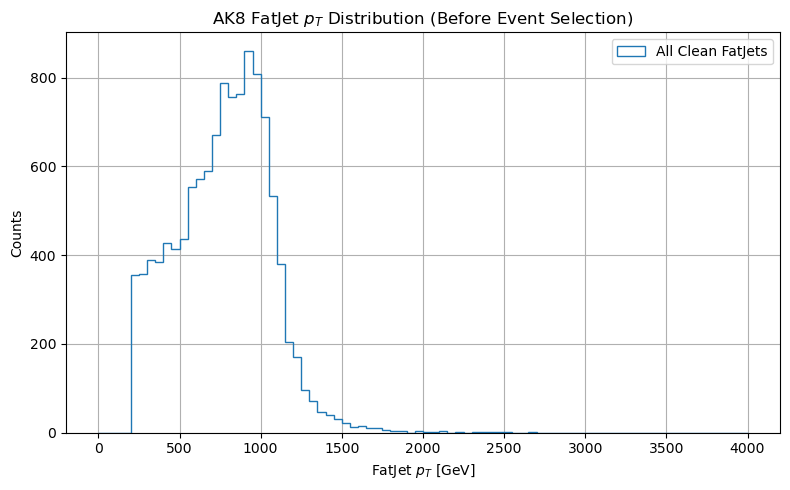

In [48]:
# Plot distribution of AK8 FatJets before applying AK8jets_candidates_mask
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=80, range=(0, 4000),
         histtype='step', label='All Clean FatJets')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("AK8 FatJet $p_T$ Distribution (Before Event Selection)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

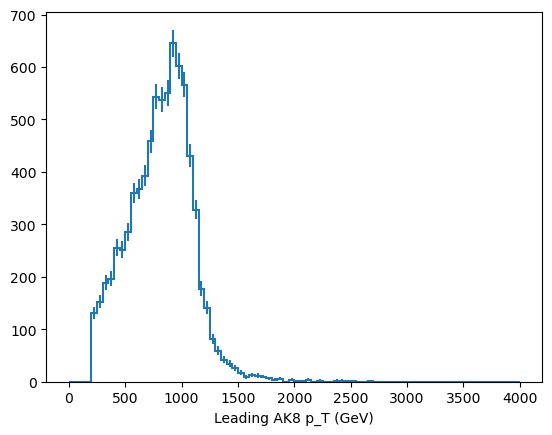

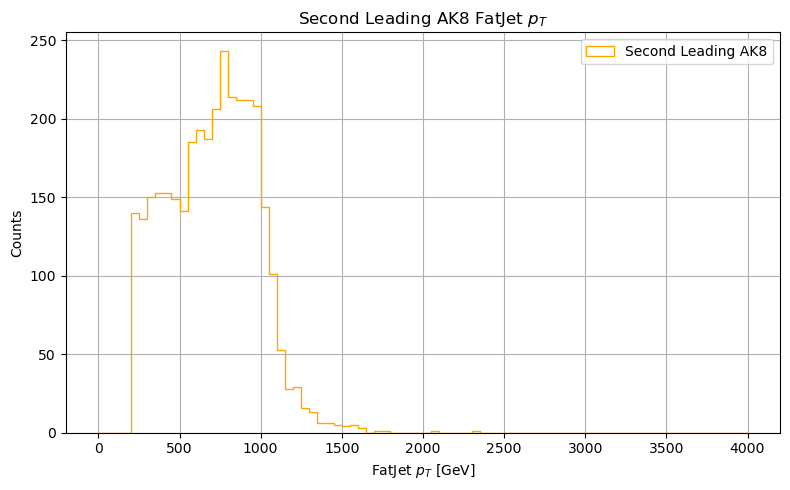

In [49]:
# Plot leading AK8 jet
leading_W_pt_hist = hist.Hist(hist.axis.StrCategory(name='dataset', label="Dataset", categories=[], growth=True),
                            hist.axis.Regular(name='leading_AK8_pt', label='Leading AK8 p_T (GeV)', bins=80, start=0, stop=4000))
leading_W_pt_hist.fill(dataset=test_dataset, leading_AK8_pt=leading_W_jet_pt)
leading_W_pt_hist.plot1d()

# Plot second-leading AK8 jet
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(second_W_jet_pt), bins=80, range=(0, 4000),
         histtype='step', color='orange', label='Second Leading AK8')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Second Leading AK8 FatJet $p_T$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

### *––––STEP 3: Event Catagorization: Define Semi-Leptonic and Hadronic Categories Using AK8 Jets ––––*

In [50]:
#tight lepton masks (already defined these earlier in the notebook)
n_tight_muons = ak.num(muons_tight)
n_tight_electrons = ak.num(electrons_tight)

# event masks
semi_leptonic_mask = (
    ((n_tight_muons == 1) & (n_tight_electrons == 0)) |
    ((n_tight_muons == 0) & (n_tight_electrons == 1))) & (ak.num(clean_fatJets) >= 1)

fully_hadronic_mask = (
    (n_tight_muons == 0) & (n_tight_electrons == 0) &
    (ak.num(clean_fatJets) >= 2))

In [51]:
# semi-leptonic W decay: 
semi_leptonic_fatjets = clean_fatJets[semi_leptonic_mask]
# fully hadronic W decay: 
fully_hadronic_fatjets = clean_fatJets[fully_hadronic_mask]

In [52]:
# For plotting (flatten to leading/subleading jets)
semi_leptonic_leading_jet = semi_leptonic_fatjets[:, 0]
fully_hadronic_leading_jet = fully_hadronic_fatjets[:, 0]
# assumes there are at least two AK8 jets in the event
fully_hadronic_second_jet = fully_hadronic_fatjets[:, 1]

### *––––STEP 4: Calculate and Plot relevant variables––––*

#### kinematic variables

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_181/583182277.py:4: SyntaxWarning: invalid escape sequence '\e'
  "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),


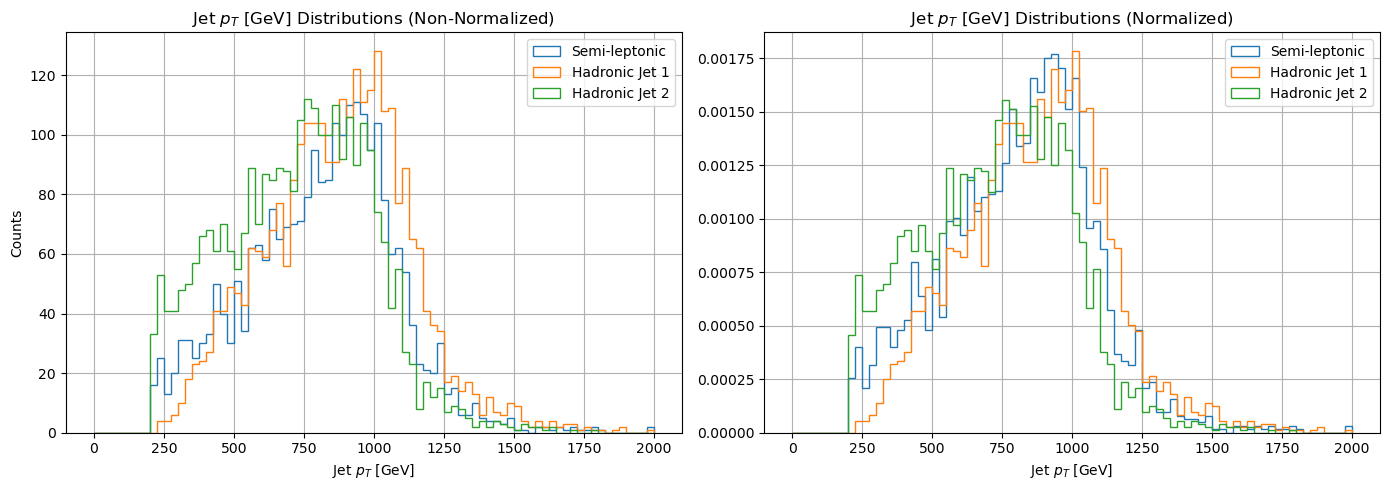

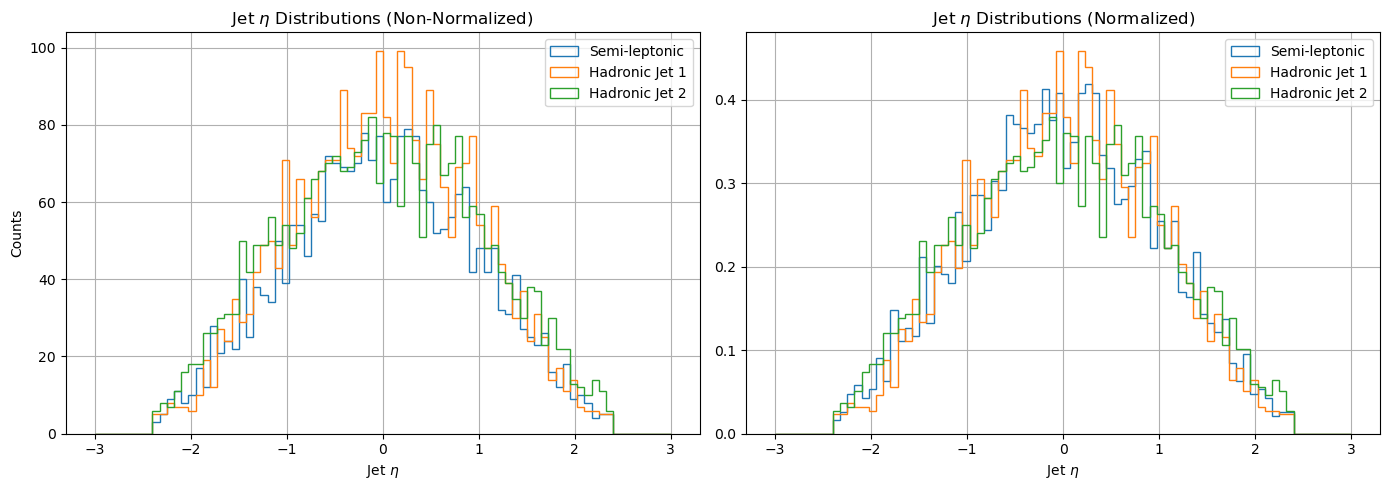

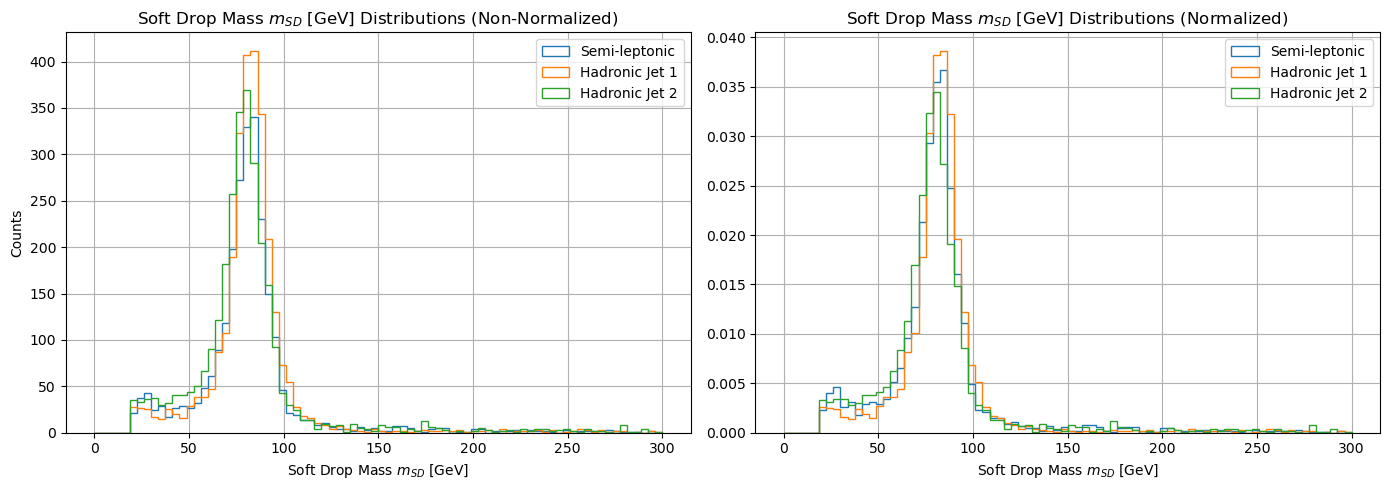

In [53]:
# dict mapping jet properties to axis labels, plot ranges, and access functions
jet_sets = {
    "pt": ("Jet $p_T$ [GeV]", (0, 2000), lambda jet: jet.pt),
    "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),
    "msoftdrop": ("Soft Drop Mass $m_{SD}$ [GeV]", (0, 300), lambda jet: jet.msoftdrop)
}
# loop over each jet parameter to generate plots
for key, (xlabel, rng, accessor) in jet_sets.items():
    plt.figure(figsize=(14, 5))
    
    # left: non-normalized
    plt.subplot(1, 2, 1)
    plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=80, range=rng,
             histtype='step', label='Semi-leptonic')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=80, range=rng,
             histtype='step', label='Hadronic Jet 1')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=80, range=rng,
             histtype='step', label='Hadronic Jet 2')
    plt.title(f"{xlabel} Distributions (Non-Normalized)")
    plt.xlabel(xlabel)
    plt.ylabel("Counts")
    plt.legend()
    plt.grid(True)

    # right: normalized
    plt.subplot(1, 2, 2)
    plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Semi-leptonic')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Hadronic Jet 1')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Hadronic Jet 2')
    plt.title(f"{xlabel} Distributions (Normalized)")
    plt.xlabel(xlabel)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#### cos$\theta$ * calculation and plotting

In [54]:
# -- Subjet Pair Extraction for Semi-Leptonic Events --
def extract_semi_subjet_pairs(fatjets, all_subjets, category_name="Semi-Leptonic"):
    pairs = []
    n_skipped = 0

    for event_fjs, event_sjs in zip(fatjets, all_subjets):
        # skip if there are no fat jets in this event
        if len(event_fjs) == 0:
            continue
        
        fj = event_fjs[0]   # leading AK8
        
        idx1, idx2 = int(fj.subJetIdx1), int(fj.subJetIdx2)

        if idx1 < 0 or idx2 < 0 or idx1 >= len(event_sjs) or idx2 >= len(event_sjs):
            n_skipped += 1
            continue

        # index
        sj1, sj2 = event_sjs[idx1], event_sjs[idx2]
        # build vectors
        vec1 = vector.obj(pt   = sj1["pt"],eta  = sj1["eta"],phi  = sj1["phi"],mass = sj1["mass"])
        vec2 = vector.obj(pt   = sj2["pt"],eta  = sj2["eta"],phi  = sj2["phi"],mass = sj2["mass"])
        pairs.append((vec1, vec2))

    print(f"[{category_name}] Valid subjet pairs: {len(pairs)}, Skipped: {n_skipped}")
    return pairs

# -- Subjet Pair Extraction for Hadronic Events --
def extract_had_subjet_pairs(fatjets, category_name="Hadronic"):
    valid_pairs = []
    n_skipped = 0

    for subjets in fatjets.subjets:
        if len(subjets) < 2:
            n_skipped += 1
            continue
        try:
            sj1, sj2 = subjets[0], subjets[1]
            vec1 = vector.obj(pt=sj1["pt"], eta=sj1["eta"], phi=sj1["phi"], mass=sj1["mass"])
            vec2 = vector.obj(pt=sj2["pt"], eta=sj2["eta"], phi=sj2["phi"], mass=sj2["mass"])
            valid_pairs.append((vec1, vec2))
        except (KeyError, TypeError, ValueError):
            n_skipped += 1

    print(f"[{category_name}] Valid subjet pairs: {len(valid_pairs)}, Skipped: {n_skipped}")
    return valid_pairs

In [55]:
# -- Extract Pairs from Each Jet Category --
semi_pairs = extract_semi_subjet_pairs(semi_leptonic_fatjets, events.SubJet[semi_leptonic_mask], "Semi-Leptonic")
had1_pairs = extract_had_subjet_pairs(fully_hadronic_leading_jet, "Hadronic Lead")
had2_pairs = extract_had_subjet_pairs(fully_hadronic_second_jet, "Hadronic Sublead")

[Semi-Leptonic] Valid subjet pairs: 2514, Skipped: 0
[Hadronic Lead] Valid subjet pairs: 2881, Skipped: 0
[Hadronic Sublead] Valid subjet pairs: 2881, Skipped: 0


In [56]:
# -- Compute cos(θ*) for Given Subjet Pairs --
def compute_cos_theta_star_from_vectors(subjet_pairs, category_name=""):
    cos_theta_star = []
    n_success = 0
    n_skipped = 0

    for i, (vec1, vec2) in enumerate(subjet_pairs):
        # 1) Reconstruct the W four-vector in the lab frame
        w_lab = vec1 + vec2
        if w_lab.mass < 1e-3 or w_lab.E <= 1e-6:
            n_skipped += 1

        # 2) Build the boost to the W rest frame
        beta3 = -w_lab.to_beta3()
        if beta3.mag < 1e-6:
            n_skipped += 1
            continue
        
        # 3) RAPIDITY SORT: pick the subjet that’s more “backward” in η
        #    (this ensures the dot can go negative when it should)
        if vec1.rapidity < vec2.rapidity:
            q = vec1  
        else:
            q = vec2

        # 4) Boost that chosen subjet into the W rest frame
        q_rest = q.boost_beta3(beta3)
        if q_rest.to_beta3().mag < 1e-6:
            n_skipped += 1
            continue

        # 5) Compute signed cosθ* via vector’s unit-vector dot        
        w_hat  = w_lab.to_beta3().unit()
        q_hat  = q_rest.to_beta3().unit()
        cos_theta = q_hat.dot(w_hat)

        cos_theta_star.append(cos_theta)
        n_success += 1

    if len(cos_theta_star) > 0:
            cos_array = np.array(cos_theta_star)
            print(f"[{category_name}] Computed cosθ* for {n_success} subjet pairs, Skipped: {n_skipped}")
            print(f"[{category_name}] range: min = {cos_array.min():.3f}, max = {cos_array.max():.3f}")
            print(f"[{category_name}] Histogram counts (neg, zero, pos): "
                  f"{np.sum(cos_array < 0)}, {np.sum(cos_array == 0)}, {np.sum(cos_array > 0)}")
    return np.array(cos_theta_star)

In [57]:
# -- Compute cos(θ*) for Each Category --
cos_theta_semi = compute_cos_theta_star_from_vectors(semi_pairs, "Semi-Leptonic")
cos_theta_had1 = compute_cos_theta_star_from_vectors(had1_pairs, "Hadronic Lead")
cos_theta_had2 = compute_cos_theta_star_from_vectors(had2_pairs, "Hadronic Sublead")

[Semi-Leptonic] Computed cosθ* for 2514 subjet pairs, Skipped: 0
[Semi-Leptonic] range: min = -0.858, max = 0.858
[Semi-Leptonic] Histogram counts (neg, zero, pos): 1300, 0, 1214
[Hadronic Lead] Computed cosθ* for 2881 subjet pairs, Skipped: 0
[Hadronic Lead] range: min = -0.862, max = 0.880
[Hadronic Lead] Histogram counts (neg, zero, pos): 1437, 0, 1444
[Hadronic Sublead] Computed cosθ* for 2881 subjet pairs, Skipped: 0
[Hadronic Sublead] range: min = -0.861, max = 0.859
[Hadronic Sublead] Histogram counts (neg, zero, pos): 1383, 0, 1498


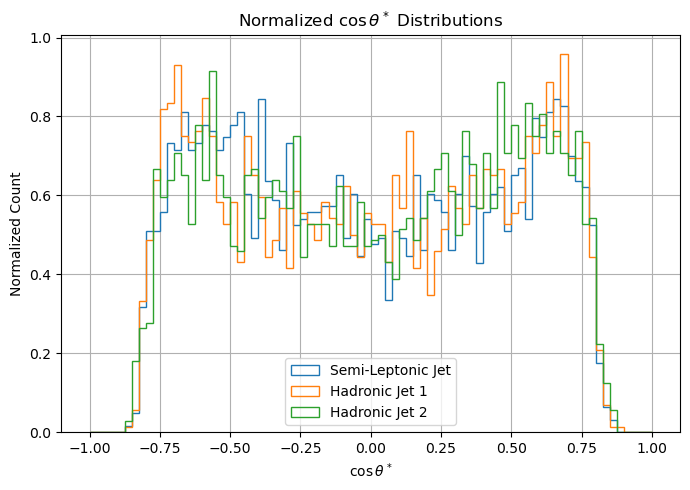

In [58]:
# -- Plot Normalized cos(θ*) Distributions --
plt.figure(figsize=(7, 5))
plt.hist(cos_theta_semi, bins=80, range=(-1, 1), density=True, histtype='step', label='Semi-Leptonic Jet')
plt.hist(cos_theta_had1, bins=80, range=(-1, 1), density=True, histtype='step', label='Hadronic Jet 1')
plt.hist(cos_theta_had2, bins=80, range=(-1, 1), density=True, histtype='step', label='Hadronic Jet 2')
plt.xlabel(r"$\cos\theta^*$")
plt.ylabel("Normalized Count")
plt.title(r"Normalized $\cos\theta^*$ Distributions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_leading_W_jet_pt.to_hdf('leading_W_jet_pt.h5', key='df', mode='w')

In [ ]:
# run this command to see if the file has been creatd
import os
os.listdir('.')